<h1 style="font-size:50px; text-align:center; padding:15px;">
    Deep Learning Tutorial - Segmentation of Brain MR Images
</h1>


In this tutorial, we will explore how **deep learning models**, particularly the **U-Net architecture**, can be applied to **automatically** segment brain tumors, from MR images.

Over the last decade, deep learning has revolutionized numerous fields, including **medical imaging**. These Deep learning solutions are increasingly being integrated into patient care, allieviating the workload of medical professionals and enhancing diagnostic accuracy.

One standout application is **automatic segmentation** which has become mainstream in medical diagnostics and treatment planning. **Manual contouring** is not only **time consuming** but also **highly subjective**, leading to **inter-observer variability**—differences in segmentation results between radiologists.

An objective delianation of the tumor by use of a AI model with soTA performance makes the longitudinal assessment of **tumor progression** and its **response to treatment** much more **robust**.


<h1 style="font-size:25px; padding:5px;">
   But What is segmentation ?
</h1>

Segmentation is a key task in medical image analysis, where an image is divided into meaningful regions, typically to identify structures like **organs**, or **tumors**. In **brain tumor segmentation**, the goal is to separate the tumor from healthy brain tissue in MRI scans.

Unlike **classification** (which labels an entire image), or **detection** (which identifies object locations), segmentation provides a **pixel-wise mask**, which is crucial for treatment planning, and disease monitoring.

<div style="text-align: center;">
    <img src="https://github.com/marsvn/PythonM2-jour4/blob/main/resources/classification%20vs%20detection%20vs%20segmentation.jpeg?raw=1" alt="Classification vs Detection vs Segmentation" width="800px">
</div>

In image segmentation, a deep learning model learns to classify each pixel in an image as belonging to a specific category :

<div style="text-align: center;">
    <img src="https://github.com/marsvn/PythonM2-jour4/blob/main/resources/segmentation.png?raw=1" alt="Classification vs Detection vs Segmentation" width="800px">
</div>

<h1 style="font-size:25px; padding:5px;">
The BraTS Challenge: Brain Tumor Segmentation Benchmark 🧠🎯
</h1>

The **Brain Tumor Segmentation (BraTS) Challenge** is an international competition designed to advance the development of **automated brain tumor segmentation models**. It provides researchers with standardized datasets and evaluation metrics to compare different deep-learning approaches.

The labels L1, L2, and L4 refer to different types of tumor structures annotated in the MRI scans. Specifically:

- **L1 (NCR/NET - Necrotic and Non-Enhancing Tumor Core)** : Represents the necrotic (dead) tumor core and the non-enhancing tumor regions.

- **L2 (ED - Peritumoral Edema)** : Represents peritumoral edema, which is swelling around the tumor due to fluid accumulation.
It often surrounds the tumor and appears as hyperintense regions in FLAIR sequences.
- **L4 (ET - Enhancing Tumor)** : Represents the enhancing tumor region, which is the actively growing part of the tumor.
It appears as a bright region in contrast-enhanced MRI (T1ce) scans.


<div style="text-align: center;">
    <img src="https://github.com/marsvn/PythonM2-jour4/blob/main/resources/BRats.png?raw=1" alt="two different subjects from the BraTS dataset" width="800px">
</div>

## 🧠 Exercise 0: Visualizing a BraTS Patient's MRI Scans

- Load **multi-modal MRI scans** (T1, T1gd, T2, FLAIR) from a BraTS patient in the folder (example BraTS patients).
- Extract an **axial-slice** (middle cross section).
- Visualize different **MRI sequences side by side** along with the slice's corresponding mask

In [1]:
!git clone https://github.com/marsvn/PythonM2-jour4.git

Cloning into 'PythonM2-jour4'...
remote: Enumerating objects: 636, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 636 (delta 1), reused 1 (delta 0), pack-reused 630 (from 4)
Receiving objects: 100% (636/636), 81.94 MiB | 16.24 MiB/s, done.
Resolving deltas: 100% (4/4), done.
Updating files: 100% (18/18), done.


In [2]:
!pip install nibabel

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
!unzip /content/drive/MyDrive/data_jour4.zip -d /content

Streaming output truncated to the last 5000 lines.
  inflating: /content/data_jour4/train/masks/patient_292_0114.nii.gz  
  inflating: /content/data_jour4/train/masks/patient_292_0115.nii.gz  
  inflating: /content/data_jour4/train/masks/patient_292_0116.nii.gz  
  inflating: /content/data_jour4/train/masks/patient_292_0117.nii.gz  
  inflating: /content/data_jour4/train/masks/patient_292_0118.nii.gz  
  inflating: /content/data_jour4/train/masks/patient_292_0119.nii.gz  
  inflating: /content/data_jour4/train/masks/patient_292_0120.nii.gz  
  inflating: /content/data_jour4/train/masks/patient_292_0121.nii.gz  
  inflating: /content/data_jour4/train/masks/patient_292_0122.nii.gz  
  inflating: /content/data_jour4/train/masks/patient_292_0123.nii.gz  
  inflating: /content/data_jour4/train/masks/patient_292_0124.nii.gz  
  inflating: /content/data_jour4/train/masks/patient_292_0125.nii.gz  
  inflating: /content/data_jour4/train/masks/patient_292_0126.nii.gz  
  inflating: /content/data

In [4]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# Patient name :
patient_name = "BraTS19_CBICA_AAG_1"

# Paths to MRI scans and the masks data :
dict_mri_paths = {
    imaging: fr"PythonM2-jour4/example BraTS patients/{patient_name}/{patient_name}_{imaging}.nii.gz"
    for imaging in ["t1", "t1ce", "t2", "flair"]
}

path_seg = fr"PythonM2-jour4/example BraTS patients/{patient_name}/{patient_name}_seg.nii.gz"     # mask file

# Load the images using nibabel :
dict_mri_images = {
    imaging: nib.load(dict_mri_paths[imaging]).get_fdata()
    for imaging in ["t1", "t1ce", "t2", "flair"]
}

img_seg = nib.load(path_seg).get_fdata()

In [5]:
# the Slice Index :
slice_idx = 55  # Extracting the middle axial slice

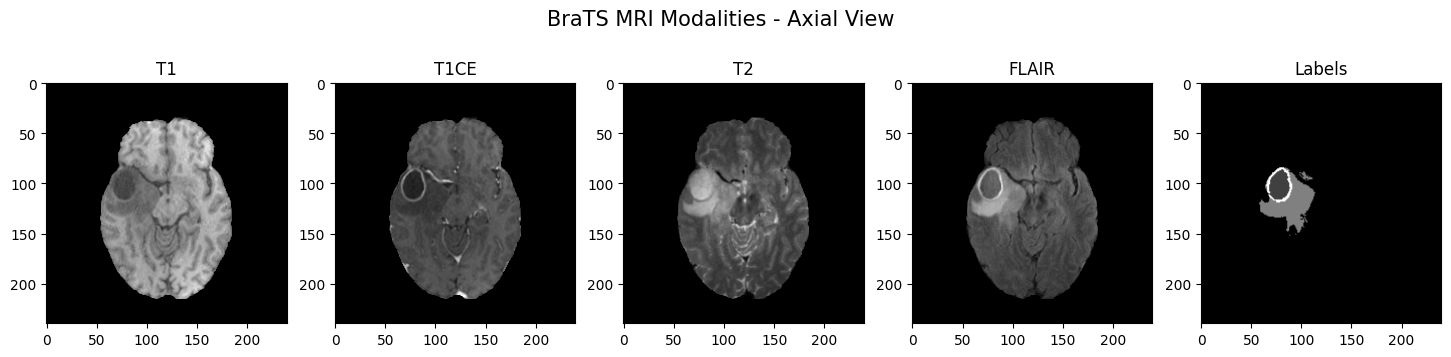

In [6]:
# Plot the MRI slices and the Labels data :
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, imaging in enumerate(["t1", "t1ce", "t2", "flair"]):

    axes[i].imshow(dict_mri_images[imaging][:, :, slice_idx].T, cmap="gray")
    axes[i].set_title(imaging.upper())

axes[4].imshow(img_seg[:, :, slice_idx].T, cmap="gray")
axes[4].set_title("Labels")

plt.suptitle("BraTS MRI Modalities - Axial View", fontsize=15)
plt.show()


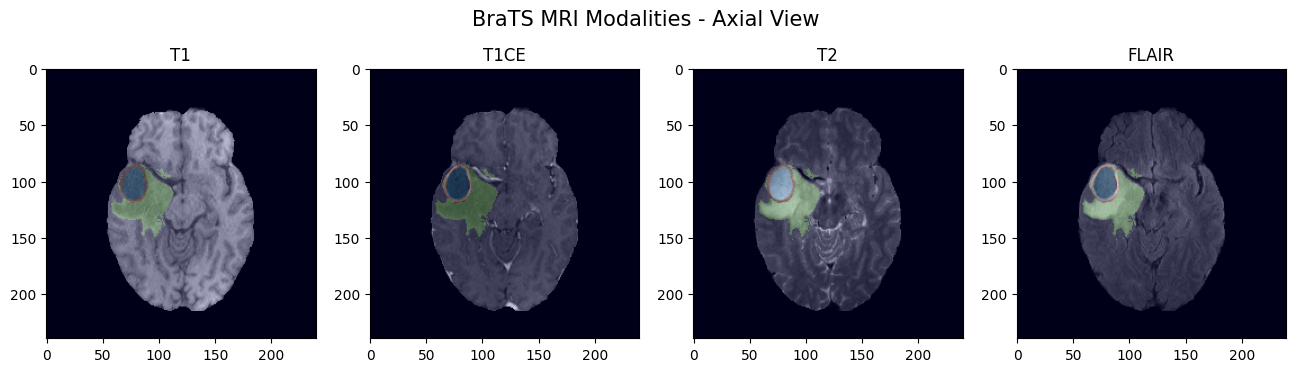

In [7]:
# Plot the MRI slices with the Labels overlayed on the mri image :
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, imaging in enumerate(["t1", "t1ce", "t2", "flair"]):

    axes[i].imshow(dict_mri_images[imaging][:, :, slice_idx].T, cmap="gray")
    axes[i].imshow(img_seg[:, :, slice_idx].T, cmap="jet", alpha=0.2)
    axes[i].set_title(imaging.upper())

plt.suptitle("BraTS MRI Modalities - Axial View", fontsize=15)
plt.show()


In this tutorial, we'll simplify the BraTS challenge, as we will attempt to predict the **L4 (ET - Enhancing Tumor)** based on the T1CE imaging, using the U-Net architecture :

<h1 style="font-size:15px; padding:5px;">
   Dataset Details
</h1>

The dataset used in this tutorial consists of T1CE MRI brain scans from 335 patients.

- Each patient has multiple **2D slices** extracted from their **3D T1CE MRI scan**.

- The naming convention (patient_XXX_YYYY.nii.gz) indicates:
    - **XXX** → Patient ID
    - **YYYY** → Slice number within that patient’s scan.



The dataset is organized into two main folders :

- **Train** - Contains images and corresponding segmentation masks from **284** patients, for training the deep learning model.
- **Test**  - Contains images and segmentation masks from **51** patients, for evaluating the model after training

Each subset is further divided into:

- Images: Contains 2D slices of the brain MRI scans.
  
- Masks: Contains the corresponding binary segmentation masks, where:
    - 1 (White) represents the enhancing tumor region .
    - 0 (Black) represents all tissue that is not enhancing tumor .
    
├── data
    
    ├── train
    │   ├── images
    │   │   ├── patient_001_0001.nii.gz
    │   │   ├── patient_001_0002.nii.gz
    │   │   ├── ...
    │   ├── masks
    │   │   ├── patient_001_0001.nii.gz
    │   │   ├── patient_001_0002.nii.gz
    │   │   ├── ...
    ├── test
    │   ├── images
    │   │   ├── patient_251_0001.nii.gz
    │   │   ├── patient_251_0002.nii.gz
    │   │   ├── ...
    │   ├── masks
    │   │   ├── patient_251_0001.nii.gz
    │   │   ├── patient_251_0002.nii.gz
    │   │   ├── ...
    

<h1 style="font-size:15px; padding:5px;">
   U-Net Architecture
</h1>

By the end of this tutorial, you will:

    - Learn about the U-Net architecture
    - Implement a U-Net architecture in python using PyTorch
    - Train and evaluate the segmentation performance using relevant metrics

## 🧠 Exercise 1: Split the train dataset into training images and validation images :

When training a deep learning model, our goal is to create a model that performs well not just on the training data, but also on unseen data (test set).

If we only evaluate performance on the training set, we risk **overfitting**, where the model memorizes the training data instead of learning meaningful patterns.

To ensure our deep learning model generalizes well to new, unseen data, we need to split our training dataset into two subsets:

- **Training Set**  – Used to train the model.
- **Validation Set**  – Used to evaluate model performance during **training** .

We will implement a **Patient-based Splitting** to ensure that all slices from a single patient belong **only to either training or validation**, not both :


In [8]:
from sklearn.model_selection import train_test_split
import random
import os


# List of slice names for both training and test :
list_original_train_slices = os.listdir("data_jour4/train/images")
list_test_slices = os.listdir("data_jour4/test/images")

# Extract patients IDs that correspond to the training set :
list_original_train_ids = list(set(
    [slice_name.split("_")[1] for slice_name in list_original_train_slices]
))

# Split the training patients into training and validation sets (e.g., 80%, 20%)
# random_state=42 ensures that the split is always the same. This is useful for reproducibility.
list_train_ids, list_val_ids = train_test_split(list_original_train_ids, test_size=0.2, random_state=42)

list_train_slices = [slice_name for slice_name
                     in list_original_train_slices
                     if slice_name.split("_")[1] in list_train_ids]

list_val_slices = [slice_name for slice_name
                   in list_original_train_slices
                   if slice_name.split("_")[1] in list_val_ids]

print(fr"Number of slices in the training set : {len(list_train_slices)}")
print(fr"Number of slices in the validation set : {len(list_val_slices)}")
print(fr"Number of slices in the testing set : {len(list_test_slices)}")


Number of slices in the training set : 32015
Number of slices in the validation set : 7988
Number of slices in the testing set : 7225


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super(UNet, self).__init__()

        # Encoder (Downsampling)
        self.enc1 = self.conv_block(in_channels, 32)
        self.enc2 = self.conv_block(32, 64)
        self.enc3 = self.conv_block(64, 128)
        self.enc4 = self.conv_block(128, 256)
        self.enc5 = self.conv_block(256, 320)

        # Bottleneck
        self.bottleneck = self.conv_block(320, 320)

        # Decoder (Upsampling)
        self.up1 = nn.ConvTranspose2d(320, 256, kernel_size=2, stride=2)
        self.dec1 = self.conv_block(512, 256)  # (256+256=512)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = self.conv_block(256, 128)  # (128+128=256)

        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec3 = self.conv_block(128, 64)  # (64+64=128)

        self.up4 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec4 = self.conv_block(64, 32)  # (32+32=64)

        # Output layer
        self.out = nn.Conv2d(32, out_channels, kernel_size=1)

        # MaxPooling
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        # Encoding Path
        x1 = self.enc1(x)
        x2 = self.enc2(self.maxpool(x1))
        x3 = self.enc3(self.maxpool(x2))
        x4 = self.enc4(self.maxpool(x3))
        x5 = self.enc5(self.maxpool(x4))

        # Bottleneck
        x = self.bottleneck(x5)

        # Decoding Path
        x = self.up1(x)
        x = torch.cat((x, x4), dim=1)  # (256+256=512)
        x = self.dec1(x)

        x = self.up2(x)
        x = torch.cat((x, x3), dim=1)  # (128+128=256)
        x = self.dec2(x)

        x = self.up3(x)
        x = torch.cat((x, x2), dim=1)  # (64+64=128)
        x = self.dec3(x)

        x = self.up4(x)
        x = torch.cat((x, x1), dim=1)  # (32+32=64)
        x = self.dec4(x)

        # Output Layer: Return raw logits (do not apply sigmoid here)
        return self.out(x)

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),  # Optional: Batch Norm for stability
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),  # Optional: Batch Norm for stability
            nn.ReLU(inplace=True)
        )


In [10]:
# Create U-Net model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = UNet(in_channels=1, out_channels=1).to(device)


cuda


In [11]:
# Print Model Summary
from torchsummary import summary
summary(model, input_size=(1, 240, 240))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 240, 240]             320
       BatchNorm2d-2         [-1, 32, 240, 240]              64
              ReLU-3         [-1, 32, 240, 240]               0
            Conv2d-4         [-1, 32, 240, 240]           9,248
       BatchNorm2d-5         [-1, 32, 240, 240]              64
              ReLU-6         [-1, 32, 240, 240]               0
         MaxPool2d-7         [-1, 32, 120, 120]               0
            Conv2d-8         [-1, 64, 120, 120]          18,496
       BatchNorm2d-9         [-1, 64, 120, 120]             128
             ReLU-10         [-1, 64, 120, 120]               0
           Conv2d-11         [-1, 64, 120, 120]          36,928
      BatchNorm2d-12         [-1, 64, 120, 120]             128
             ReLU-13         [-1, 64, 120, 120]               0
        MaxPool2d-14           [-1, 64,

In [12]:
import torch.optim as optim

# Define the loss function
criterion = nn.BCEWithLogitsLoss()

# Define the optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [13]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import nibabel as nib
import albumentations as A

class BratsDataset(Dataset):
    def __init__(self, images_dir, masks_dir, slice_list, transform=None):

        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.slice_list = slice_list
        self.transform = transform

    def __len__(self):
        return len(self.slice_list)

    def __getitem__(self, idx):
        slice_name = self.slice_list[idx]
        image_path = os.path.join(self.images_dir, slice_name)
        mask_path = os.path.join(self.masks_dir, slice_name)

        # Load the NIfTI files
        image_nii = nib.load(image_path)
        image_data = image_nii.get_fdata().astype(np.float32)

        mask_nii = nib.load(mask_path)
        mask_data = mask_nii.get_fdata().astype(np.float32)

        # Add a channel dimension: shape becomes [1, H, W]
        image_data = np.expand_dims(image_data, axis=0)
        mask_data = np.expand_dims(mask_data, axis=0)

        # Convert the NumPy arrays to PyTorch tensors
        image_tensor = torch.tensor(image_data, dtype=torch.float32)
        mask_tensor = torch.tensor(mask_data, dtype=torch.float32)

        # Optionally, apply any additional transforms (these transforms should work on tensors)
        if self.transform:
            augmented = self.transform(image=image_data, mask=mask_data)
            image_data = augmented['image']
            mask_data = augmented['mask']

        # Since the mask is already binary, no additional thresholding is necessary.
        return image_tensor, mask_tensor


/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.4' (you have '2.0.3'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [20]:
images_dir = "data_jour4/train/images"
masks_dir = "data_jour4/train/masks"

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    # A.Affine(
    #     translate_percent={"x": (-0.0625, 0.0625), "y": (-0.0625, 0.0625)},
    #     scale=(0.9, 1.1),
    #     rotate=(-45, 45),
    #     p=0.75
    # ),
    # A.ElasticTransform(alpha=1, sigma=50, p=0.5)
])


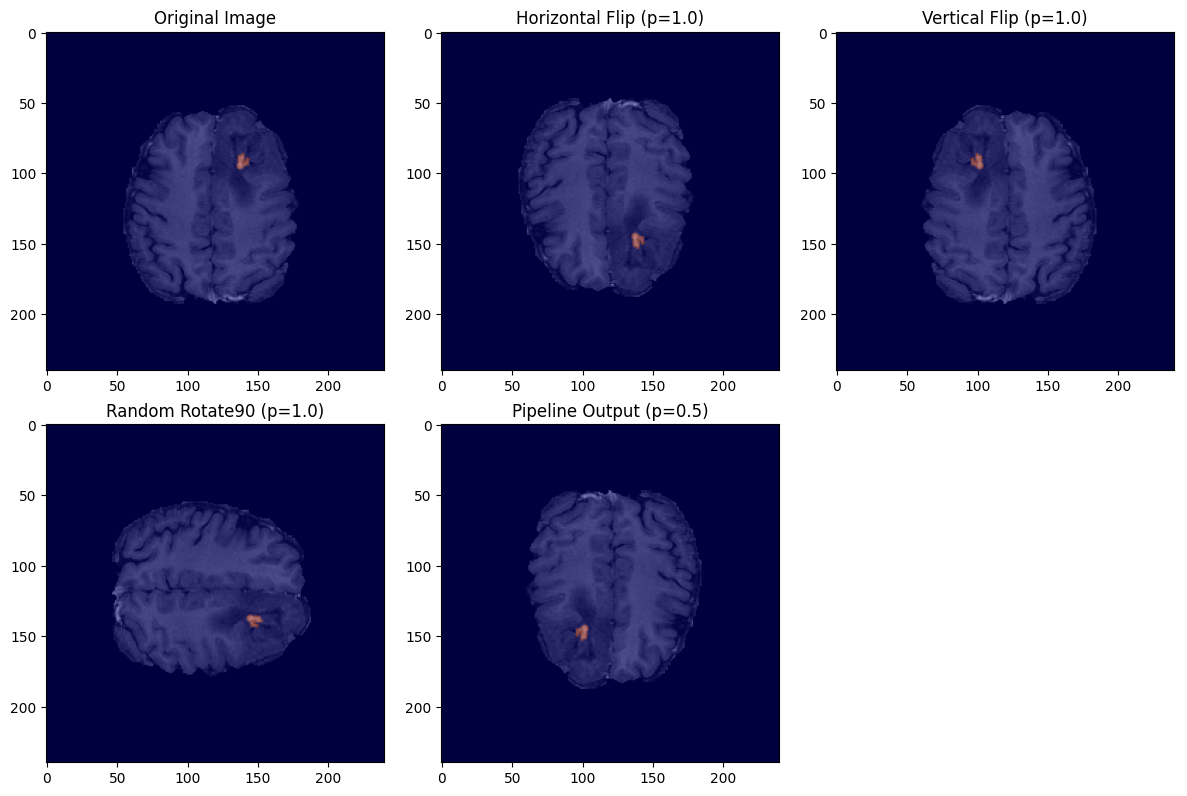

In [21]:
# Visualize data augmentation

## Load an a slice from a patient as an example :
example = "patient_001_0100.nii.gz"
image_path, mask_path = f"data_jour4/train/images/{example}", f"data_jour4/train/masks/{example}"
image_nii, mask_nii = nib.load(image_path), nib.load(mask_path)
image = image_nii.get_fdata().astype(np.float32)
mask = mask_nii.get_fdata().astype(np.float32)


# Define individual transformations with p=1.0 for visualization
hflip = A.HorizontalFlip(p=1.0)      # Always flip horizontally
vflip = A.VerticalFlip(p=1.0)        # Always flip vertically
rotate90 = A.RandomRotate90(p=1.0)     # Always rotate by a multiple of 90 degrees

# # Apply each transformation individually
hflip_aug = hflip(image=image, mask=mask)
img_hflip, mask_hflip = hflip_aug["image"], hflip_aug["mask"]

vflip_aug = vflip(image=image, mask=mask)
img_vflip, mask_vflip = vflip_aug["image"], vflip_aug["mask"]

rotate90_aug = rotate90(image=image, mask=mask)
img_rotate90, mask_rotate90 = rotate90_aug["image"], rotate90_aug["mask"]

# Apply the composed pipeline (output will vary because of randomness)
pipeline_aug = train_transform(image=image, mask=mask)
img_pipeline, mask_pipeline = pipeline_aug["image"], pipeline_aug["mask"]

# Visualize the results with overlayed masks
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

axes[0].imshow(image.T, cmap="gray")
axes[0].imshow(mask.T, cmap="jet", alpha=0.5)
axes[0].set_title("Original Image")

axes[1].imshow(img_hflip.T, cmap="gray")
axes[1].imshow(mask_hflip.T, cmap="jet", alpha=0.5)
axes[1].set_title("Horizontal Flip (p=1.0)")

axes[2].imshow(img_vflip.T, cmap="gray")
axes[2].imshow(mask_vflip.T, cmap="jet", alpha=0.5)
axes[2].set_title("Vertical Flip (p=1.0)")

axes[3].imshow(img_rotate90.T, cmap="gray")
axes[3].imshow(mask_rotate90.T, cmap="jet", alpha=0.5)
axes[3].set_title("Random Rotate90 (p=1.0)")

axes[4].imshow(img_pipeline.T, cmap="gray")
axes[4].imshow(mask_pipeline.T, cmap="jet", alpha=0.5)
axes[4].set_title("Pipeline Output (p=0.5)")

# Hide the unused subplot
axes[5].axis("off")

plt.tight_layout()
plt.show()


In [22]:
# Create dataset instances
train_dataset = BratsDataset(
    images_dir=images_dir,
    masks_dir=masks_dir,
    slice_list=list_train_slices,
    transform=train_transform
)

val_dataset = BratsDataset(
    images_dir=images_dir,
    masks_dir=masks_dir,
    slice_list=list_val_slices,
    transform=None
)

In [23]:
# Create DataLoader objects
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

for images, masks in train_dataloader:
    print(f"Images batch shape: {images.shape}")  # Expected: [batch_size, 1, H, W]
    print(f"Masks batch shape: {masks.shape}")      # Expected: [batch_size, 1, H, W]

    break

Images batch shape: torch.Size([16, 1, 240, 240])
Masks batch shape: torch.Size([16, 1, 240, 240])


In [24]:
import tqdm as tqdm

num_epochs = 1

# Placeholders for loss history
train_loss_history = []
val_loss_history = []

# Initialize best validation loss with a large number
best_val_loss = float('inf')

for epoch in range(num_epochs):
    # --------------------------
    # Training Phase
    # --------------------------
    model.train()  # Set model to training mode
    train_losses = []

    with tqdm.tqdm(total=len(train_dataloader), desc=f"Epoch {epoch + 1}/{num_epochs}", unit="batch") as pbar:
        for inputs, labels in train_dataloader:
            # Move data to the device
            inputs, labels = inputs.to(device), labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)

            # Compute loss
            loss = criterion(outputs, labels)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            # Save the loss and update progress bar
            train_losses.append(loss.item())
            pbar.update(1)
            pbar.set_postfix({"training_loss": loss.item()})

    # Compute average training loss for the epoch
    avg_train_loss = sum(train_losses) / len(train_losses)
    train_loss_history.append(avg_train_loss)

    # --------------------------
    # Validation Phase
    # --------------------------
    print("Validation in progress ...")
    model.eval()  # Set model to evaluation mode
    val_losses = []

    # Disable gradient computation for validation
    with torch.no_grad():
        with tqdm.tqdm(total=len(val_dataloader), desc=f"Validation Epoch {epoch + 1}/{num_epochs}", unit="batch") as pbar_val:
            for inputs, labels in val_dataloader:
                # Move data to the device
                inputs, labels = inputs.to(device), labels.to(device)

                # Forward pass
                outputs = model(inputs)

                # Compute loss
                loss = criterion(outputs, labels)
                val_losses.append(loss.item())

                pbar_val.update(1)
                pbar_val.set_postfix({"validation_loss": loss.item()})

    # Compute average validation loss for the epoch
    avg_val_loss = sum(val_losses) / len(val_losses)
    val_loss_history.append(avg_val_loss)

    print(f"Epoch {epoch + 1}/{num_epochs} - Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}")

    # --------------------------
    # Save Model Checkpoints
    # --------------------------
    # Save the last model after each epoch
    torch.save(model.state_dict(), "last_model.pth")

    # If the current validation loss is the best so far, save the model as the best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print(f"Best model updated at epoch {epoch + 1} with validation loss {avg_val_loss:.4f}")


Epoch 1/1: 100%|██████████| 2001/2001 [11:36<00:00,  2.87batch/s, training_loss=0.00224]


Validation in progress ...


Validation Epoch 1/1: 100%|██████████| 500/500 [01:11<00:00,  6.97batch/s, validation_loss=0.00269]


Epoch 1/1 - Training Loss: 0.0300, Validation Loss: 0.0038
Best model updated at epoch 1 with validation loss 0.0038


In [28]:
# Create the test dataset and dataloader
test_images_dir = "data_jour4/test/images"
test_masks_dir  = "data_jour4/test/masks"

test_dataset = BratsDataset(
    images_dir=test_images_dir,
    masks_dir=test_masks_dir,
    slice_list=list_test_slices,
    transform=None
)

test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)


In [29]:
def compute_dice(outputs, targets, eps=1e-6):

    # Convert the logits to probability using sigmoid
    outputs = torch.sigmoid(outputs)

    # Convert probabilities to binary masks
    outputs = (outputs > 0.5).float()
    targets = targets.float()

    # Compute intersection and union per sample
    intersection = (outputs * targets).sum(dim=(1, 2))
    union = outputs.sum(dim=(1, 2)) + targets.sum(dim=(1, 2))

    # Compute dice coefficient for each sample and then average over the batch
    dice = (2.0 * intersection + eps) / (union + eps)
    return dice.mean()


In [31]:
model.eval()
test_dice_scores = []
tumor_examples = []  # to save examples for visualization

with torch.no_grad():
    for inputs, labels in test_dataloader:

        inputs, labels = inputs.to(device), labels.to(device)

        # Forward pass
        outputs = model(inputs)
        # Squeeze out the channel dimension: now (B, H, W)
        outputs = outputs.squeeze(1)
        labels = labels.squeeze(1)

        # Check if the ground truth has any tumor pixels
        if labels.sum() > 0:
            # Compute Dice coefficient for this batch (or single sample, if batch_size==1)
            dice = compute_dice(outputs, labels)
            #print(fr"GT volume: {labels.sum().item()} -- Dice score: {dice:.4f}")
            test_dice_scores.append(dice)

            # Save example for visualization (convert to cpu for plotting)
            # We'll save the first image in the batch
            tumor_examples.append((inputs.cpu(), outputs.cpu(), labels.cpu(), dice))
        #else:
        #print("No tumor in slice, skipping dice calculation.")

# Compute average Dice over all tumor-containing test slices
avg_test_dice = sum(test_dice_scores) / len(test_dice_scores)
print(f"\nTest Dice on tumor slices: {avg_test_dice:.4f}")



Test Dice on tumor slices: 0.5273


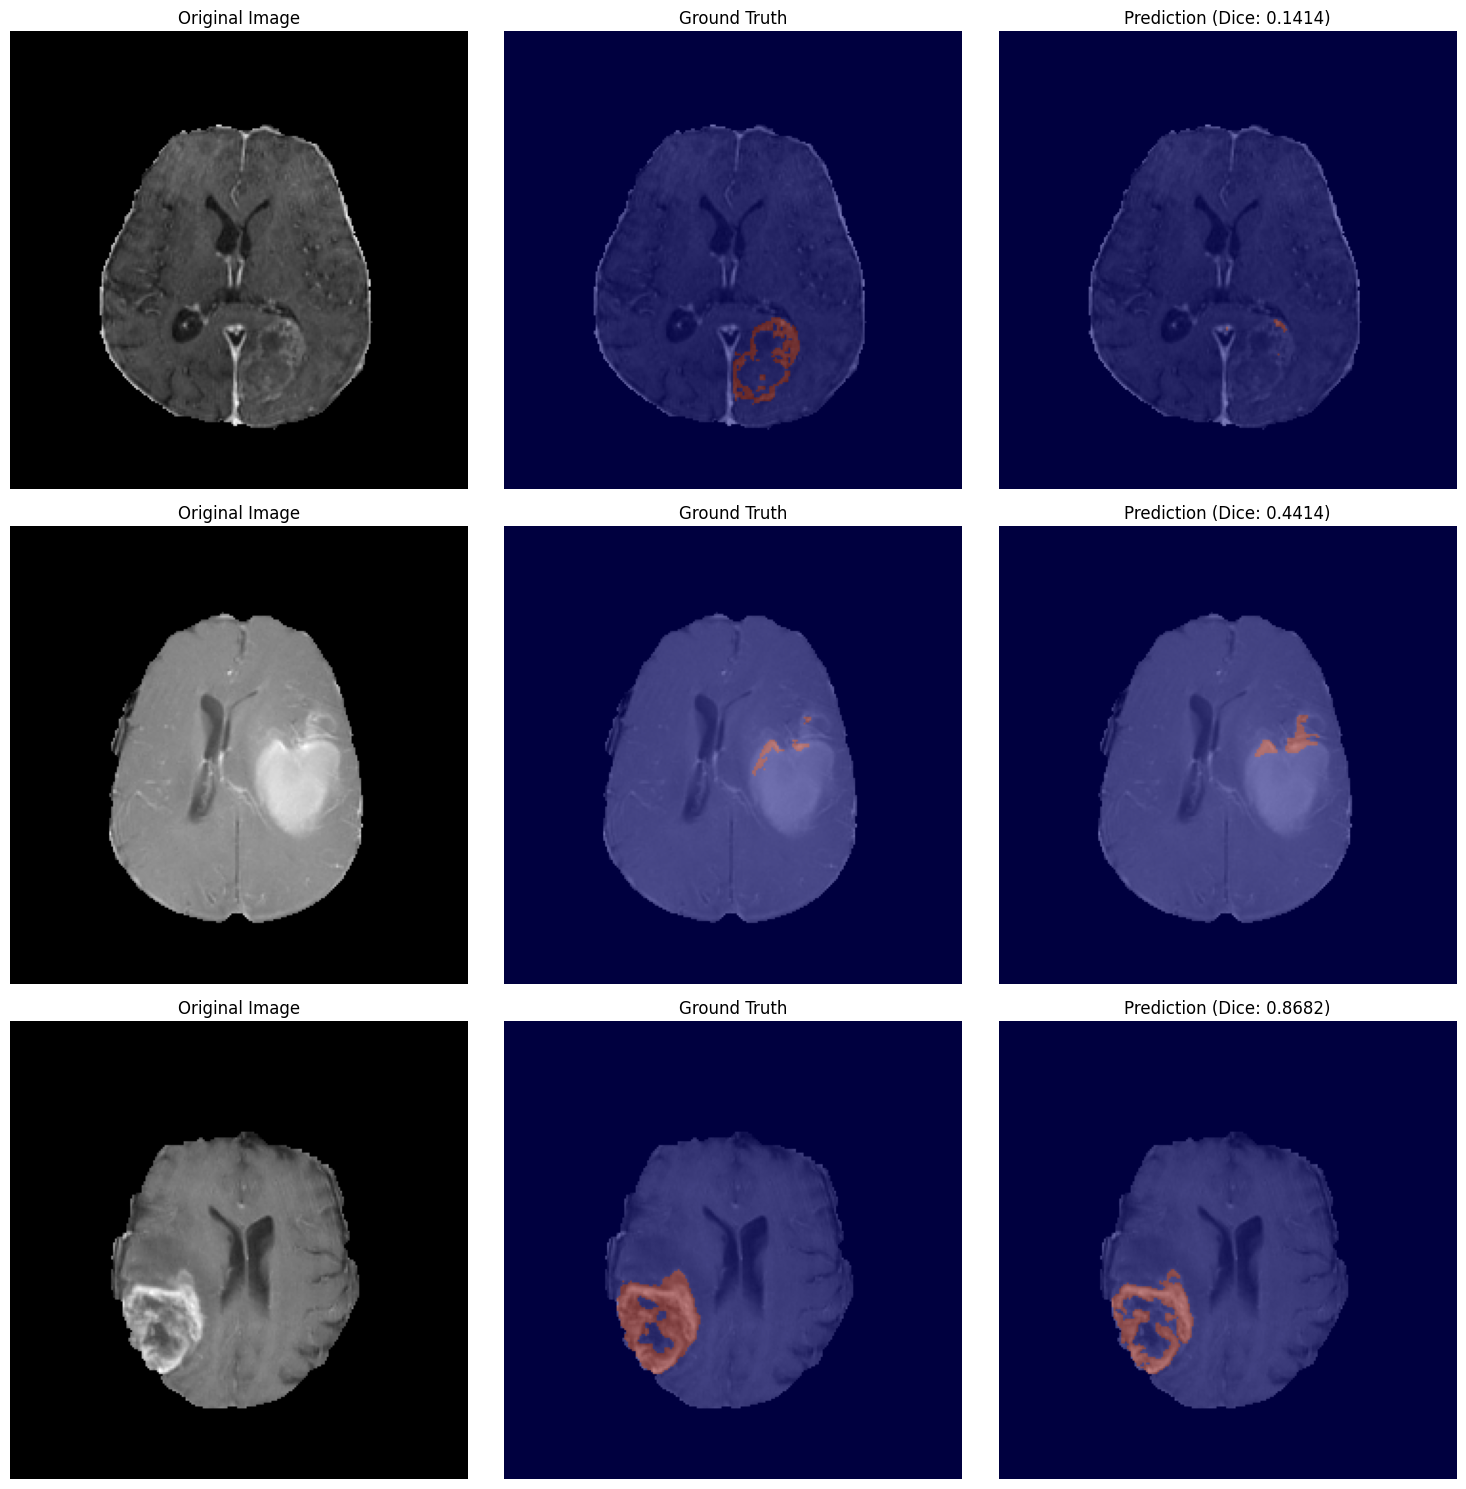

In [32]:
# ------------------------------
# Visualize a few examples (only those with tumors)
# ------------------------------
num_examples = min(3, len(tumor_examples))

fig, axes = plt.subplots(num_examples, 3, figsize=(15, 5*num_examples))

# If only one example, ensure axes is 2D
if num_examples == 1:
    axes = np.expand_dims(axes, axis=0)

for i in range(num_examples):
    inp, pred, gt, dice = tumor_examples[i]
    # Assume batch size is >= 1; take the first sample in the batch.
    # Convert to numpy arrays for visualization.
    img = inp[0, 0, :, :].numpy()            # Original image
    gt_mask = gt[0].numpy()                   # Ground truth mask
    # Threshold prediction (it might still be probabilities)
    pred_mask = (pred[0] > 0.5).float().numpy()

    # Original image
    axes[i, 0].imshow(img.T, cmap="gray")
    axes[i, 0].set_title("Original Image")
    axes[i, 0].axis("off")

    # Ground truth overlay
    axes[i, 1].imshow(img.T, cmap="gray")
    axes[i, 1].imshow(gt_mask.T, cmap="jet", alpha=0.5)
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis("off")

    # Prediction overlay with Dice score
    axes[i, 2].imshow(img.T, cmap="gray")
    axes[i, 2].imshow(pred_mask.T, cmap="jet", alpha=0.5)
    axes[i, 2].set_title(fr"Prediction (Dice: {dice:.4f})")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()


In [33]:
from scipy.spatial.distance import directed_hausdorff


def hausdorff_distance(outputs, targets):

    if torch.is_tensor(outputs):
        outputs = outputs.cpu().numpy()
    if torch.is_tensor(targets):
        targets = targets.cpu().numpy()

    # Get coordinates where mask==1
    coords_outputs = np.argwhere(outputs > 0)
    coords_targets = np.argwhere(targets > 0)

    # If one of the masks is empty, return nan (or a large number)
    if len(coords_outputs) == 0 or len(coords_targets) == 0:
        return np.nan

    d1 = directed_hausdorff(coords_outputs, coords_targets)[0]
    d2 = directed_hausdorff(coords_targets, coords_outputs)[0]
    return max(d1, d2)


In [35]:
# Load the trained model :
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load("PythonM2-jour4/best_model_12022025.pth", map_location=device))
model.to(device)
model.eval()


<ipython-input-35-c1e14d3610ab>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("PythonM2-jour4/best_model_12022025.pth", map_location=devi

UNet(
  (enc1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (enc2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (enc3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running

In [37]:
model.eval()
test_dice_scores = []
tumor_examples = []  # to save examples for visualization

with torch.no_grad():
    for inputs, labels in test_dataloader:

        inputs, labels = inputs.to(device), labels.to(device)

        # Forward pass
        outputs = model(inputs)
        # Squeeze out the channel dimension: now (B, H, W)
        outputs = outputs.squeeze(1)
        labels = labels.squeeze(1)

        # Check if the ground truth has any tumor pixels
        if labels.sum() > 0:
            # Compute Dice coefficient for this batch (or single sample, if batch_size==1)
            dice = compute_dice(outputs, labels)
            #print(fr"GT volume: {labels.sum().item()} -- Dice score: {dice:.4f}")
            test_dice_scores.append(dice)

            # Save example for visualization (convert to cpu for plotting)
            # We'll save the first image in the batch
            tumor_examples.append((inputs.cpu(), outputs.cpu(), labels.cpu(), dice))
        #else:
        #    print("No tumor in slice, skipping dice calculation.")

# Compute average Dice over all tumor-containing test slices
avg_test_dice = sum(test_dice_scores) / len(test_dice_scores)
print(f"\nTest Dice on tumor slices: {avg_test_dice:.4f}")



Test Dice on tumor slices: 0.6314


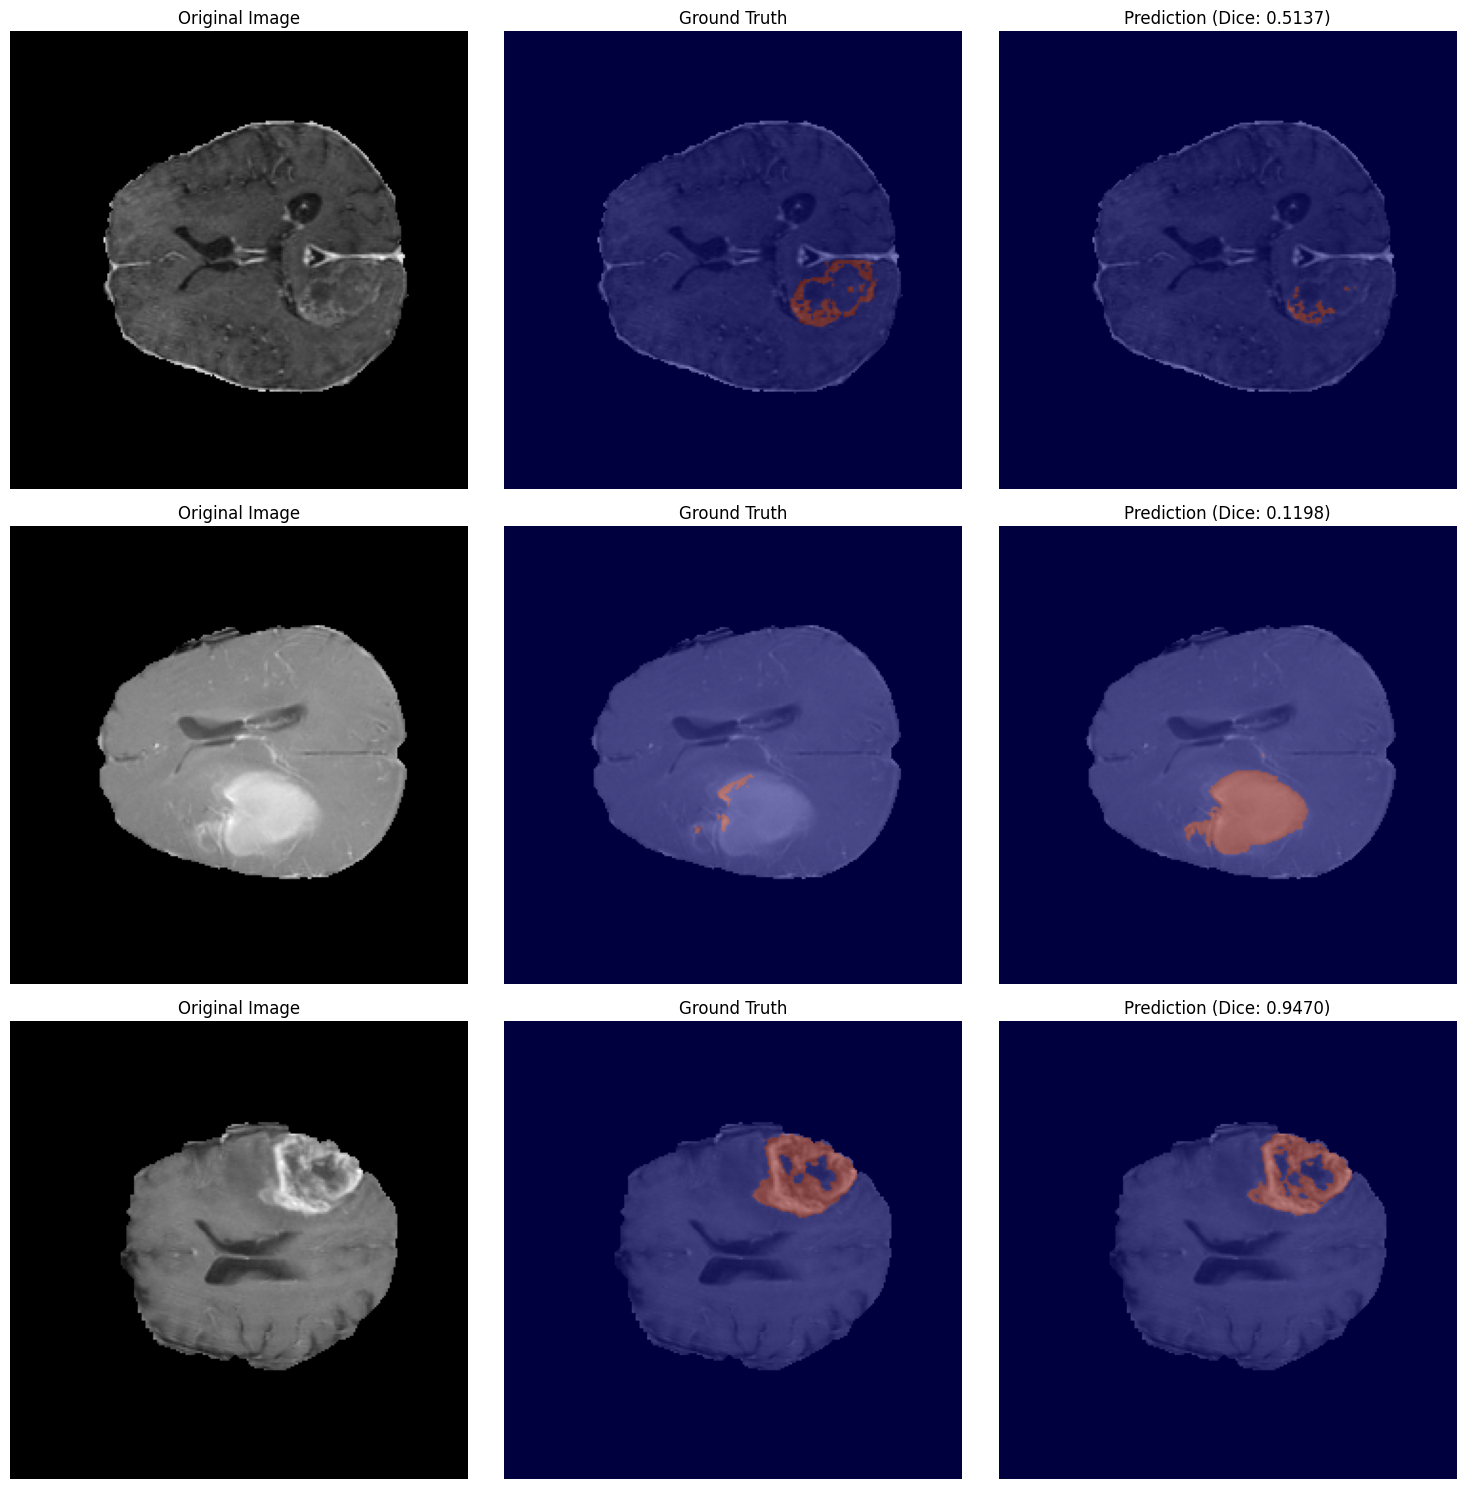

In [38]:
# ------------------------------
# Visualize a few examples (only those with tumors)
# ------------------------------
num_examples = min(3, len(tumor_examples))

fig, axes = plt.subplots(num_examples, 3, figsize=(15, 5*num_examples))

# If only one example, ensure axes is 2D
if num_examples == 1:
    axes = np.expand_dims(axes, axis=0)

for i in range(num_examples):
    inp, pred, gt, dice = tumor_examples[i]
    # Assume batch size is >= 1; take the first sample in the batch.
    # Convert to numpy arrays for visualization.
    img = inp[0, 0, :, :].numpy()            # Original image
    gt_mask = gt[0].numpy()                   # Ground truth mask
    # Threshold prediction (it might still be probabilities)
    pred_mask = (pred[0] > 0.5).float().numpy()

    # Original image
    axes[i, 0].imshow(img, cmap="gray")
    axes[i, 0].set_title("Original Image")
    axes[i, 0].axis("off")

    # Ground truth overlay
    axes[i, 1].imshow(img, cmap="gray")
    axes[i, 1].imshow(gt_mask, cmap="jet", alpha=0.5)
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis("off")

    # Prediction overlay with Dice score
    axes[i, 2].imshow(img, cmap="gray")
    axes[i, 2].imshow(pred_mask, cmap="jet", alpha=0.5)
    axes[i, 2].set_title(fr"Prediction (Dice: {dice:.4f})")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()
